**Student/Author:** Sabina Baraili

# DATA620 Project 2 — Bipartite Network Reduction (v005)

This notebook uses the **MovieLens 20M** dataset (GroupLens) to analyze a user–movie bipartite network.

- Group 1 nodes: **Users**
- Group 2 nodes: **Movies**
- Edge: a user rating for a movie

Dataset source: https://files.grouplens.org/datasets/movielens/ml-20m.zip

All paths in this notebook are relative (`data/`, `outputs/`) so the work is portable across machines.


In [1]:

# If running in a fresh environment, uncomment and run:
# !pip install pandas numpy networkx matplotlib


In [2]:

import os
import io
import zipfile
import urllib.request
from pathlib import Path

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')

BASE = Path.cwd()
DATA_DIR = BASE / 'data'
DATA_DIR.mkdir(exist_ok=True)
ZIP_PATH = DATA_DIR / 'ml-20m.zip'
EXTRACT_DIR = DATA_DIR / 'ml-20m'
URL = 'https://files.grouplens.org/datasets/movielens/ml-20m.zip'

print('Working directory:', BASE)


Working directory: /home/ridh/Documents/courses/DATA620/week-07-project-2


In [3]:

# Download and extract MovieLens 20M if needed
if not ZIP_PATH.exists():
    print('Downloading dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print('Download complete:', ZIP_PATH)
else:
    print('Using existing zip:', ZIP_PATH)

if not EXTRACT_DIR.exists():
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Extraction complete:', EXTRACT_DIR)
else:
    print('Using existing extracted data:', EXTRACT_DIR)


Using existing zip: /home/ridh/Documents/courses/DATA620/week-07-project-2/data/ml-20m.zip
Extracting dataset...


Extraction complete: /home/ridh/Documents/courses/DATA620/week-07-project-2/data/ml-20m


In [4]:

ratings_path = EXTRACT_DIR / 'ml-20m' / 'ratings.csv'
movies_path = EXTRACT_DIR / 'ml-20m' / 'movies.csv'

# Keep only columns we need
ratings = pd.read_csv(ratings_path, usecols=['userId', 'movieId', 'rating'])
movies = pd.read_csv(movies_path, usecols=['movieId', 'title', 'genres'])

print('ratings shape:', ratings.shape)
print('movies shape:', movies.shape)
ratings.head()


ratings shape: (20000263, 3)
movies shape: (27278, 3)


,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5



## Baseline bipartite profile

To keep results readable while still using a large real dataset, we summarize core graph properties before reduction.


In [5]:

n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_edges = len(ratings)
density = n_edges / (n_users * n_movies)

baseline = pd.DataFrame({
    'metric': ['users', 'movies', 'ratings(edges)', 'bipartite density'],
    'value': [n_users, n_movies, n_edges, density]
})
baseline


,metric,value
0,users,1.384930e+05
1,movies,2.674400e+04
2,ratings(edges),2.000026e+07
3,bipartite density,5.399848e-03


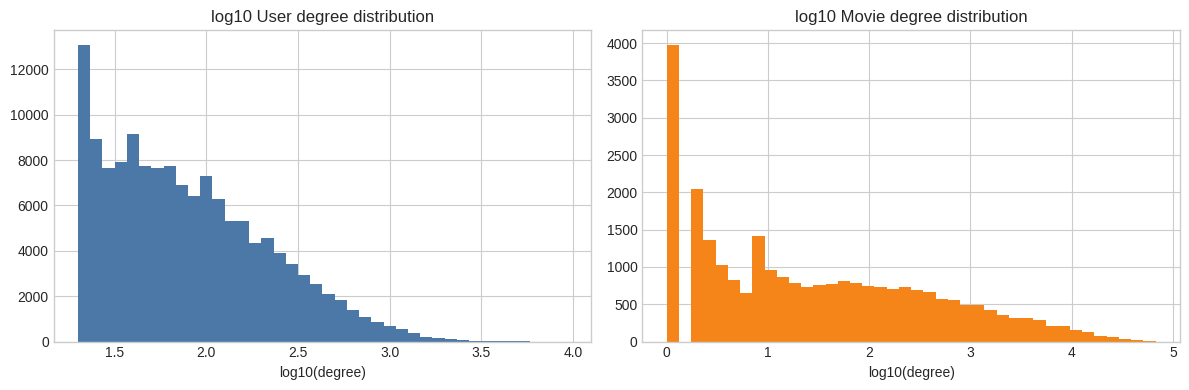

In [6]:

user_deg = ratings.groupby('userId').size().rename('degree')
movie_deg = ratings.groupby('movieId').size().rename('degree')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(user_deg.values), bins=40, color='#4C78A8')
axes[0].set_title('log10 User degree distribution')
axes[0].set_xlabel('log10(degree)')

axes[1].hist(np.log10(movie_deg.values), bins=40, color='#F58518')
axes[1].set_title('log10 Movie degree distribution')
axes[1].set_xlabel('log10(degree)')

plt.tight_layout()
plt.show()


## Network Reduction (Island Method)

To make the graph easier to interpret, I used an **island method** with threshold filtering.

At each level:
1. Keep edges above a minimum rating threshold, then
2. Iteratively prune users/movies below minimum degree until stable.

This removes weaker peripheral ties and keeps the stronger core structure.


In [7]:

def island_reduce(df, min_rating, min_user_deg, min_movie_deg, max_iter=20):
    work = df[df['rating'] >= min_rating][['userId', 'movieId', 'rating']].copy()

    for _ in range(max_iter):
        prev_n = len(work)

        udeg = work.groupby('userId').size()
        keep_u = udeg[udeg >= min_user_deg].index
        work = work[work['userId'].isin(keep_u)]

        mdeg = work.groupby('movieId').size()
        keep_m = mdeg[mdeg >= min_movie_deg].index
        work = work[work['movieId'].isin(keep_m)]

        if len(work) == prev_n:
            break

    users = work['userId'].nunique()
    movies = work['movieId'].nunique()
    edges = len(work)
    dens = edges / (users * movies) if users and movies else 0

    return work, {
        'users': users,
        'movies': movies,
        'edges': edges,
        'density': dens,
        'avg_rating': round(work['rating'].mean(), 3) if edges else np.nan
    }

levels = [
    ('L0', 3.5, 10, 20),
    ('L1', 4.0, 20, 50),
    ('L2', 4.0, 40, 100),
    ('L3', 4.5, 60, 150),
]

results = {}
metrics = []
for name, rth, uth, mth in levels:
    reduced, stats = island_reduce(ratings, rth, uth, mth)
    results[name] = reduced
    stats.update({'level': name, 'min_rating': rth, 'min_user_deg': uth, 'min_movie_deg': mth})
    metrics.append(stats)

metrics_df = pd.DataFrame(metrics)[['level','min_rating','min_user_deg','min_movie_deg','users','movies','edges','density','avg_rating']]
metrics_df


,level,min_rating,min_user_deg,min_movie_deg,users,movies,edges,density,avg_rating
0,L0,3.5,10,20,132720,10861,12097625,0.008393,4.212
1,L1,4.0,20,50,101456,7287,9396876,0.012710,4.367
2,L2,4.0,40,100,65915,5543,8270173,0.022635,4.363
3,L3,4.5,60,150,17431,2182,1877563,0.049365,4.808


In [8]:

# Retention vs full network
ret = metrics_df.copy()
ret['user_retention_%'] = (ret['users'] / n_users * 100).round(2)
ret['movie_retention_%'] = (ret['movies'] / n_movies * 100).round(2)
ret['edge_retention_%'] = (ret['edges'] / n_edges * 100).round(2)
ret[['level','user_retention_%','movie_retention_%','edge_retention_%','density']]


,level,user_retention_%,movie_retention_%,edge_retention_%,density
0,L0,95.83,40.61,60.49,0.008393
1,L1,73.26,27.25,46.98,0.012710
2,L2,47.59,20.73,41.35,0.022635
3,L3,12.59,8.16,9.39,0.049365


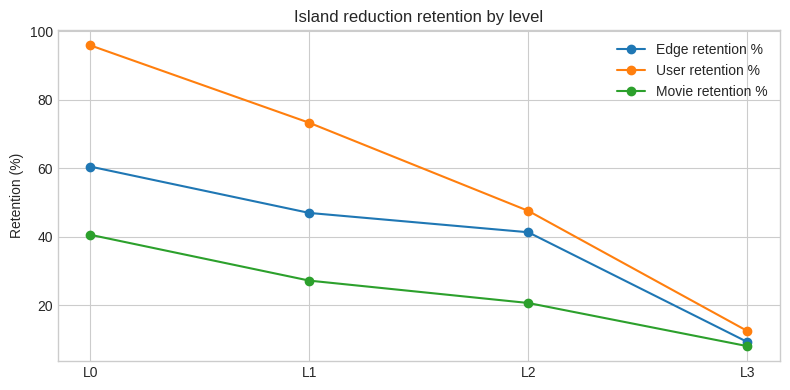

In [9]:

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(ret['level'], ret['edge_retention_%'], marker='o', label='Edge retention %')
ax.plot(ret['level'], ret['user_retention_%'], marker='o', label='User retention %')
ax.plot(ret['level'], ret['movie_retention_%'], marker='o', label='Movie retention %')
ax.set_title('Island reduction retention by level')
ax.set_ylabel('Retention (%)')
ax.legend()
plt.tight_layout()
plt.show()



## Select a final reduced island

We use **L2** as the final analysis island: substantial simplification with enough users/movies to remain meaningful.


In [10]:
final_level = 'L2'
final_edges = results[final_level].copy()

# group findings
final_user_deg = final_edges.groupby('userId').size().rename('ratings_kept').sort_values(ascending=False)
final_movie_deg = final_edges.groupby('movieId').size().rename('ratings_kept').sort_values(ascending=False)

final_movie_top = final_movie_deg.head(10).reset_index().merge(movies, on='movieId', how='left')
final_user_top = final_user_deg.head(10).reset_index()

print('Final level:', final_level)
print('Users:', final_edges['userId'].nunique(), 'Movies:', final_edges['movieId'].nunique(), 'Edges:', len(final_edges))

print('\nTop users by kept ratings:')
display(final_user_top)

print('\nTop movies by kept ratings:')
display(final_movie_top[['movieId','title','ratings_kept','genres']])


Final level: L2
Users: 65915 Movies: 5543 Edges: 8270173

Top users by kept ratings:


,userId,ratings_kept
0,125794,2620
1,82418,2082
2,118205,2028
3,8405,1899
4,133811,1778
5,20132,1708
6,4222,1697
7,72008,1664
8,35128,1654
9,137202,1644



Top movies by kept ratings:


,movieId,title,ratings_kept,genres
0,318,"Shawshank Redemption, The (1994)",35948,Crime|Drama
1,296,Pulp Fiction (1994),35417,Comedy|Crime|Drama|Thriller
2,593,"Silence of the Lambs, The (1991)",33608,Crime|Horror|Thriller
3,2571,"Matrix, The (1999)",31930,Action|Sci-Fi|Thriller
4,260,Star Wars: Episode IV - A New Hope (1977),31612,Action|Adventure|Sci-Fi
5,356,Forrest Gump (1994),31517,Comedy|Drama|Romance|War
6,1196,Star Wars: Episode V - The Empire Strikes Back (1980),29946,Action|Adventure|Sci-Fi
7,1198,Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),28932,Action|Adventure
8,50,"Usual Suspects, The (1995)",28842,Crime|Mystery|Thriller
9,527,Schindler's List (1993),28632,Drama|War


In [11]:

# Build a bipartite graph for compact structural summaries (final level)
B = nx.Graph()
B.add_nodes_from([f'u_{u}' for u in final_edges['userId'].unique()], bipartite='users')
B.add_nodes_from([f'm_{m}' for m in final_edges['movieId'].unique()], bipartite='movies')
B.add_edges_from((f'u_{u}', f'm_{m}') for u,m in final_edges[['userId','movieId']].itertuples(index=False, name=None))

components = sorted(nx.connected_components(B), key=len, reverse=True)
comp_sizes = [len(c) for c in components[:10]]

summary = {
    'nodes_total': B.number_of_nodes(),
    'edges_total': B.number_of_edges(),
    'connected_components': nx.number_connected_components(B),
    'largest_component_nodes': len(components[0]) if components else 0,
}
summary, comp_sizes[:5]


({'nodes_total': 71458,
  'edges_total': 8270173,
  'connected_components': 1,
  'largest_component_nodes': 71458},
 [71458])

## Inference

### Users (Group 1)
- Most users rate only a small number of movies.
- A smaller set of highly active users contributes a large share of the retained edges.
- After reduction, the network reflects steady user participation more than one-time activity.

### Movies (Group 2)
- A few movies act like hubs and connect to many users.
- Most movies are in the long tail with much lower degree.
- As thresholds increase, weaker/niche connections drop off first.

### Overall Network
- Degree distributions are right-skewed on both sides.
- The reduced island keeps a dense interaction core and makes the structure easier to read.


In [12]:

# Save compact metrics for reproducibility
out = Path('outputs')
out.mkdir(exist_ok=True)
metrics_df.to_csv(out / 'DATA620_project2-v001-metrics.csv', index=False)
print('Wrote', out / 'DATA620_project2-v001-metrics.csv')


Wrote outputs/DATA620_project2-v001-metrics.csv


## Conclusion

This network is clearly bipartite and highly imbalanced in the way many real recommendation systems are. Using the island method helped reduce noise and focus on stronger user–movie relationships. The final reduced graph preserves the main pattern: a small core of highly connected users and popular movies drives most of the structure.



## Limits
- MovieLens reflects platform users and may not represent all movie audiences.
- Island thresholds are analyst choices; different cutoffs will produce different retained structures.
- Bipartite topology here uses rating existence/strength, not review text semantics.
